# Data Exploration: 
*NOTE* 

This notebook is used to:
- Test `wfdb` reading of local records
- Plot raw signals and signal windows (30s)
- Visualize windows and example segments
- Inspect label / annotation counts to explore class imbalance

Quick start:
1. Open this notebook in VS Code or Jupyter and select a Python kernel with the project environment.
2. Install dependencies if needed:

   pip install wfdb matplotlib numpy pandas

3. Run the cells in order. If your files are in a different location, set `data_dir = Path('<your_path>')` in the second code cell.

Notes:
- Cells will skip unreadable files. If a cell cannot find records, check that `data/raw/` contains WFDB `.hea`/.dat and annotation files or CSV label files.
- This notebook does not modify your data; it only reads and plots segments for inspection.

In [ ]:
"""
Setup: Import libraries and configure plotting
- numpy, pandas: Data manipulation
- wfdb: Read MIT-BIH WFDB format files (ECG records)
- matplotlib: Visualization
"""
import os
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

plt.rcParams.update({'figure.max_open_warning': 0, 'figure.figsize': (10, 4)})# Disable warning for opening many figures

data_dir = Path('../data/raw')
print('data_dir ->', data_dir.resolve())
print('Exists?', data_dir.exists())

data_dir -> C:\Users\sejal\OneDrive\Desktop\ENDG 511\ENDG-511---Alarm-Prioritization-\data\raw
Exists? True


In [ ]:
"""
Load MIT-BIH Records: Find all .hea files (WFDB headers)
- Each MIT-BIH record consists of multiple files (.hea header, .dat data, .atr annotations)
- Search for .hea files which define record metadata and location
- Extract record stems (name without extension) for wfdb to read
"""
from pathlib import Path
import glob

# Search for all .hea files (header files) in the directory
data_dir = Path('../data/raw')
hea_files = sorted(glob.glob(str(data_dir / '*.hea')))
# Print how many records were found

print(f'Found {len(hea_files)} MIT-BIH records (.hea files)')

# Extract record stems (remove extension)
record_stems = [str(Path(f).with_suffix('')) for f in hea_files]
if record_stems:
    print(f'Example stem: {Path(record_stems[0]).name}')

Found 0 MIT-BIH records (.hea files)


In [ ]:
"""
Read First MIT-BIH Record
- Use wfdb.rdsamp() to read physical signal (in millivolts)
- Extract sampling frequency (fs), signal shape, and record metadata
- Iterate until first successful read (handles any corrupt files)
"""
import wfdb
import numpy as np

sig, fields = None, None
for stem in record_stems:
    try:
        # Exctract relevant information and displays a basic summary
        sig, fields = wfdb.rdsamp(stem)
        record_id = Path(stem).name
        fs = fields['fs']
        print(f'✓ Loaded record: {record_id}')
        print(f'  Shape: {sig.shape} (samples, channels)')
        print(f'  Sampling rate: {fs} Hz')
        print(f'  Duration: {sig.shape[0]/fs:.1f} seconds')
        break
    except Exception as e:
        continue

if sig is None:
    print('Error: Could not load any MIT-BIH records. Check data/raw/ folder.')

Record: ..\data\raw\training\a103l
Signal shape (samples, channels): (82500, 3)
Sampling freq (fs): 250


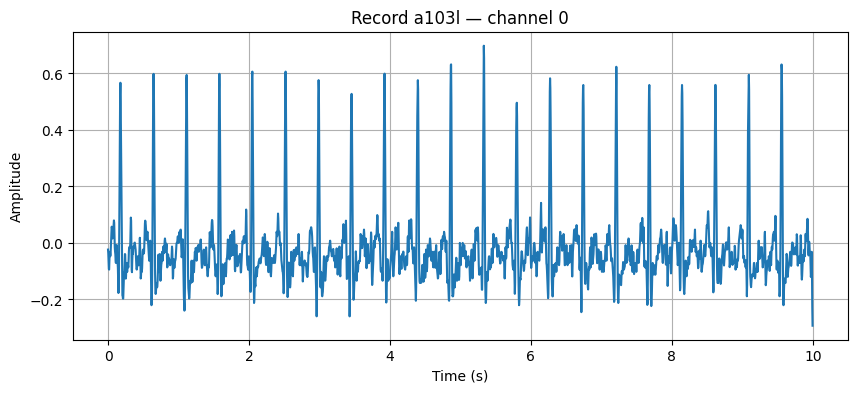

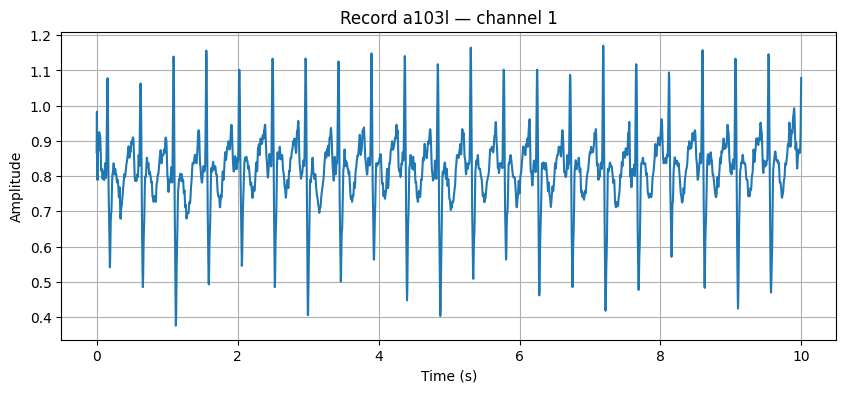

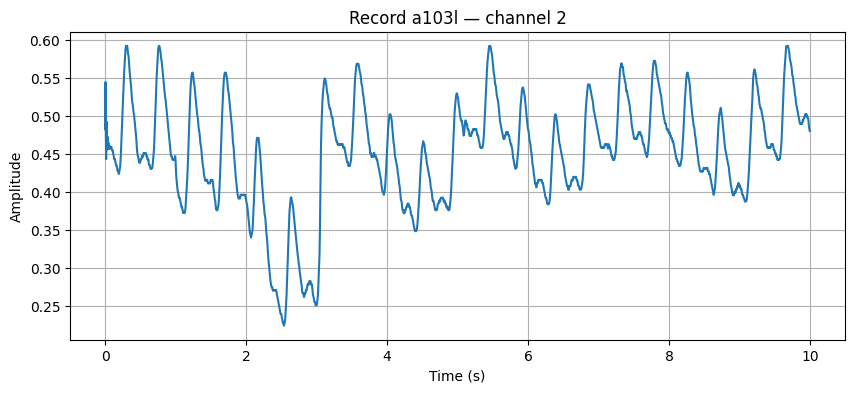

In [ ]:
"""
Visualize Raw ECG Signal (First 30 Seconds)
- Plot lead II (channel 0) of the first MIT-BIH record
- Shows unprocessed signal with all noise and ECG morphology
- Helps understand what preprocessing needs to handle
"""
if sig is not None:
    plot_seconds = 30
    samples_to_plot = min(plot_seconds * fs, sig.shape[0])
    t = np.arange(samples_to_plot) / fs
    
    plt.figure(figsize=(12, 3))
    plt.plot(t, sig[:samples_to_plot, 0], linewidth=0.8)
    plt.title(f'{record_id} - ECG Signal (Lead II)', fontsize=12, fontweight='bold')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude (mV)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Window length (samples): 7500
Number of full 30s windows in record: 11


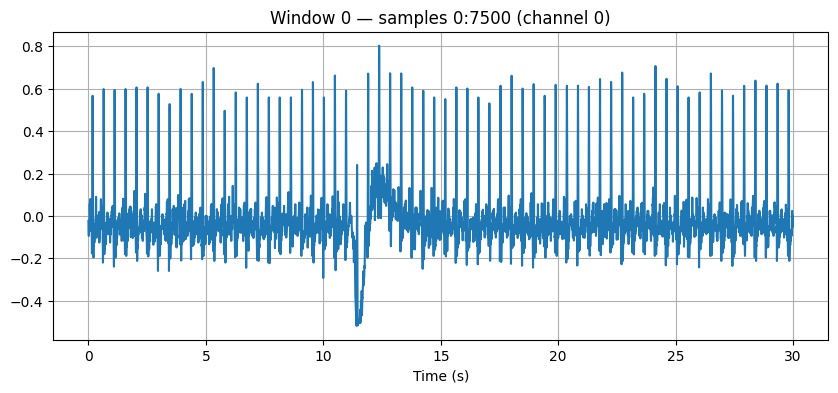

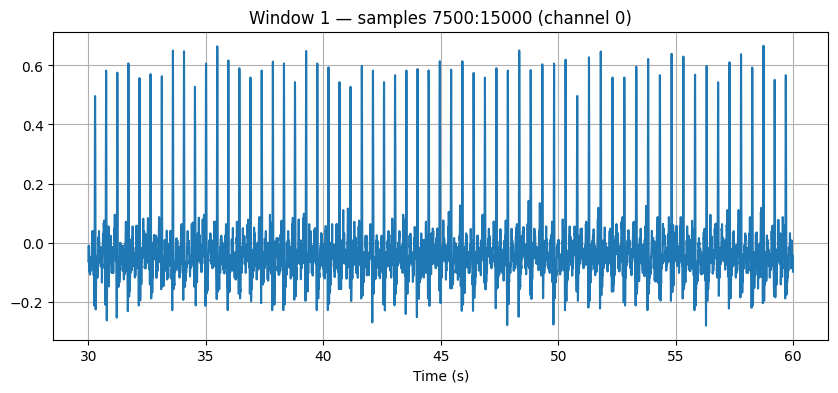

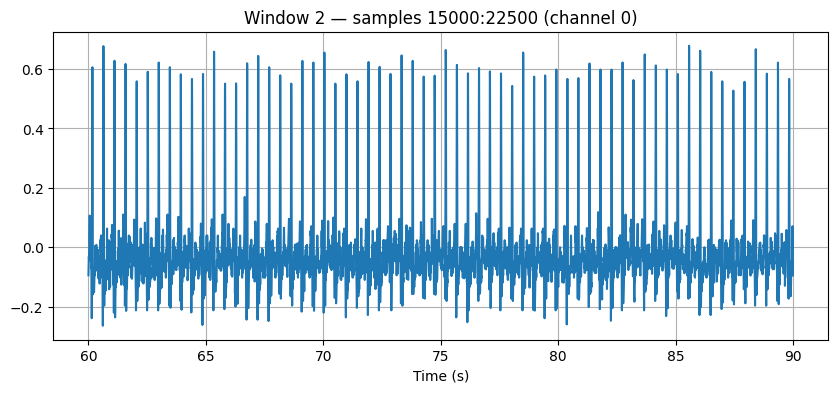

In [ ]:
"""
Display 360-Sample Beat Windows (Model Input)
- MIT-BIH uses 360 Hz sampling → 360 samples = 1 second window
- Each window centered on beat annotation (180 samples before/after)
- Show first 4 windows to visualize model input characteristics
"""
if sig is not None:
    window_len = 360  # Standard MIT-BIH window
    num_windows = sig.shape[0] // window_len
    print(f'Window length: {window_len} samples (1 second at {fs} Hz)')
    print(f'Max possible windows in this record: {num_windows}')
    
    # Plot 4 example windows
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    for idx, ax in enumerate(axes.flat):
        if idx < num_windows:
            start = idx * window_len
            stop = start + window_len
            t = np.arange(window_len) / fs
            ax.plot(t, sig[start:stop, 0], linewidth=1)
            ax.set_title(f'Window {idx}', fontweight='bold')
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Amplitude')
            ax.grid(True, alpha=0.3)
    plt.suptitle('Example 360-Sample Beat Windows', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

Class Distribution:
                 Class  Count  Percentage
          Low (Normal)  11161       64.59
          Medium (SVT)   1263        7.31
Critical (Ventricular)   4856       28.10

  Imbalance Ratio (Low/Critical): 2x


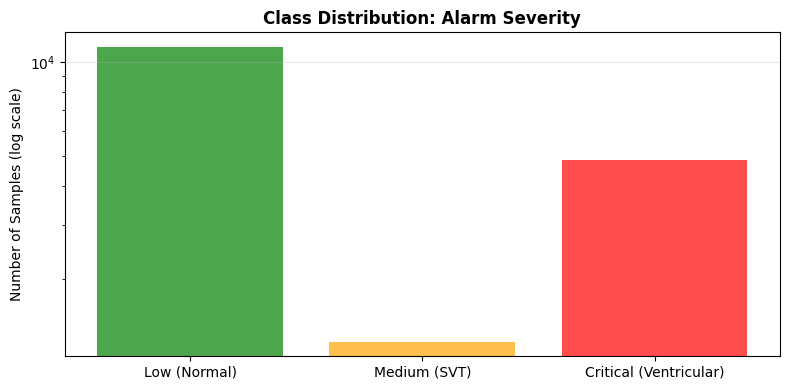

In [ ]:
"""
Analyze Class Imbalance: THE Core Problem in Alarm Prioritization
- Load preprocessed MIT-BIH labels 
- Class 0 (Low): Normal rhythm, ~200x more common
- Class 1 (Medium): Atrial/Supraventricular, rare
- Class 2 (Critical): Ventricular, MOST CRITICAL (200x less common))
- This severe imbalance requires weighted loss 
"""
import pandas as pd
from collections import Counter

proc_dir = Path('../data/processed')
y_file = proc_dir / 'y_mitbih.npy'

CLASSES = {0: 'Low (Normal)', 1: 'Medium (SVT)', 2: 'Critical (Ventricular)'}

if y_file.exists():
    y = np.load(y_file)
    counts = Counter(y)
    
    # Display counts and percentages
    df_dist = pd.DataFrame({
        'Class': [CLASSES[i] for i in sorted(counts.keys())],
        'Count': [counts[i] for i in sorted(counts.keys())]
    })
    df_dist['Percentage'] = (df_dist['Count'] / df_dist['Count'].sum() * 100).round(2)
    print('Class Distribution:')
    print(df_dist.to_string(index=False))
    print(f'\n  Imbalance Ratio (Low/Critical): {counts[0]/counts[2]:.0f}x')
    
    # Visualize with log scale to show all classes
    plt.figure(figsize=(8, 4))
    plt.bar(df_dist['Class'], df_dist['Count'], color=['green', 'orange', 'red'], alpha=0.7)
    plt.title('Class Distribution: Alarm Severity', fontweight='bold')
    plt.ylabel('Number of Samples (log scale)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('Note: Run Team11_AP.ipynb first to generate processed data')